In [1]:
from common_setup import *
from pathlib import Path
import json
from statsmodels.stats.proportion import proportion_confint
from scipy.stats import binomtest


In [2]:
def normalize(v):
    norm = np.linalg.norm(v)
    if norm == 0: 
       return v
    return v / norm

def metric1(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)
    
    A = np.array([[np.sum(u*u), np.sum(u*v)], [np.sum(u*v), np.sum(v*v)]])

    e12=np.matmul(np.linalg.inv(A),np.array([np.sum(m*u), np.sum(m*v)]))
    return np.linalg.norm(m-(e12[0]*u)-(e12[1]*v))**2
    
def metric2(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)
    
    return abs(np.sum(m*u)-np.sum(m*v))

    
def metric3(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)

    A = np.array([[np.sum(u*u), np.sum(u*v)], [np.sum(u*v), np.sum(v*v)]])

    e12=np.matmul(np.linalg.inv(A),np.array([np.sum(m*u), np.sum(m*v)]))
    return (e12[0]),(e12[1]), np.linalg.norm(m-(e12[0]*u)-(e12[1]*v))

def metric4(u,v,m,):
    return np.sum(np.minimum(u,m)), np.sum(np.minimum(v,m))


def metric5(u,v,m):
    return SimilarityJS(u,m), SimilarityJS(v,m)

def metric6(u,v,m):
    return SimilarityJS(u,m,1e-4), SimilarityJS(v,m,1e-4)


def metric7(u,v,m):
    return np.sum(np.minimum(u,m))/np.sum(np.maximum(u,m)), np.sum(np.minimum(v,m))/np.sum(np.maximum(v,m))


In [3]:

def drawPairwiseChange(i, j, x):
    # This is just a sample function. Replace this with your function.
    return np.sin(i*x) + np.cos(j*x)

def InterpretPairwiseResult(y1,y2):
    if y1==1 and y2==1:
        return 'E',(0.85, 0.7, 0.7) #E : competitive exclusion
    elif y1==0 and y2==0:
        return 'E',(0.85, 0.7, 0.7) #E : competitive exclusion
    elif y1==0 and y2==1:
        return 'B',(0.7, 0.7, 0.9) #B : Bistability
    elif y1>0 and y1<1 and y2>0 and y2<1:
        return 'C',(0.7, 0.85, 0.7) #C : Coexistence
    else:
        return 'U',(0.5, 0.5, 0.5) #U : Unclassified

def mask_equal(u,v,m):
    u_m=np.array(u)>0
    v_m=np.array(v)>0
    shared=u_m*v_m
    mask1=u_m-shared*(np.array(v)/(np.array(u)+np.array(v)+1e-8))
    mask2=1-mask1
    return mask1, mask2

def NbyNcomposition(Coalescence_data, Coal_IDX_list, Sub_IDX_list):
    N=len(Sub_IDX_list)
    Coal_matrix={}
    Coal_keys={}
    Coal_mask1={}
    Coal_mask2={}
    Sub_keys={}
    Sub_matrix={}
    for SampleIDX in Coal_IDX_list:
        idx=np.where(Coalescence_data['SampleIDX']==SampleIDX)
        subSampleIDX1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()[0]
        subSampleIDX2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()[0]
        subSampleIDX1=np.where(Sub_IDX_list==subSampleIDX1)[0][0]
        subSampleIDX2=np.where(Sub_IDX_list==subSampleIDX2)[0][0]
        IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in [SampleIDX]])
        df=Processed_sequences_synthetic.iloc[IDX_list_]
        c_mix=df.values[1:].tolist()
        ID_mix=df.values[0]
        
        SampleIDX=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()[0]
        IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in [SampleIDX]])
        if (IDX_list_.size==0):
            continue
        df=Processed_sequences_synthetic.iloc[IDX_list_]
        c_1=df.values[1:].tolist()
        ID_1=df.values[0]   
        
        SampleIDX=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()[0]
        IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in [SampleIDX]])
        if (IDX_list_.size==0):
            continue
        df=Processed_sequences_synthetic.iloc[IDX_list_]
        c_2=df.values[1:].tolist()
        ID_2=df.values[0]          
        
        mask_1,mask_2=mask_equal(c_1,c_2,c_mix)
        
        
        i=min(subSampleIDX1,subSampleIDX2)
        j=max(subSampleIDX1,subSampleIDX2)
        Coal_matrix[i,j]=c_mix
        Coal_keys[i,j]=ID_mix
        Coal_mask1[i,j]=mask_1
        Coal_mask2[i,j]=mask_2
        
        
    for SampleIDX in Sub_IDX_list:
        IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in [SampleIDX]])
        if (IDX_list_.size==0):
            continue
        df=Processed_sequences_synthetic.iloc[IDX_list_]
        i=np.where(Sub_IDX_list==SampleIDX)[0][0]
        Sub_matrix[i]=df.values[1:].tolist()
        Sub_keys[i]=df.values[0]
        
    return Coal_matrix, Sub_matrix, Coal_keys, Sub_keys,Coal_mask1,Coal_mask2



In [4]:
def normalize(v):
    norm = np.linalg.norm(v)
    if norm == 0: 
       return v
    return v / norm


def metric_VectorDecomposition_onlyPositive(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)
    
    A = np.array([[np.sum(u*u), np.sum(u*v)], [np.sum(u*v), np.sum(v*v)]])

    e12=np.matmul(np.linalg.inv(A),np.array([np.sum(m*u), np.sum(m*v)]))
    
    x1=(e12[0])*(e12[0]>0)
    x2=(e12[1])*(e12[1]>0)
    x3=np.linalg.norm(m-(e12[0]*u)-(e12[1]*v))
    convert=np.sqrt((1-x3**2)/(x1**2+x2**2))
    
    return convert*x1, convert*x2, x3

def metric1(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)
    
    A = np.array([[np.sum(u*u), np.sum(u*v)], [np.sum(u*v), np.sum(v*v)]])

    e12=np.matmul(np.linalg.inv(A),np.array([np.sum(m*u), np.sum(m*v)]))
    return np.linalg.norm(m-(e12[0]*u)-(e12[1]*v))**2
    
def metric2(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)
    
    
    return abs(np.sum(m*u)-np.sum(m*v))

    
def metric3(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)

    A = np.array([[np.sum(u*u), np.sum(u*v)], [np.sum(u*v), np.sum(v*v)]])

    e12=np.matmul(np.linalg.inv(A),np.array([np.sum(m*u), np.sum(m*v)]))
    return (e12[0]),(e12[1]), np.linalg.norm(m-(e12[0]*u)-(e12[1]*v))

def metric4(u,v,m,):
    return np.sum(np.minimum(u,m)), np.sum(np.minimum(v,m))


def PolarizedPlot(data1,data2):

        f, ax = plt.subplots(1,1, figsize=(60*mm,60*mm),facecolor='w', edgecolor='k')
        ax.scatter(data1,data2, s=25,color=colors[c_i], marker='.', alpha=0.7,linewidths=0)
        ax.scatter(data2,data1, s=25,color='grey', marker='.', alpha=0.2,linewidths=0)

        # Define the grid of points
        x = np.linspace(-0.15, 1.2, 500)
        y = np.linspace(-0.15, 1.2, 500)
        X, Y = np.meshgrid(x, y)

        # Calculate the radius from the origin
        R = np.sqrt(abs(X**2 + Y**2))
        contour = plt.contour(X, Y, R, levels=[0.25, 0.5, 0.75, 1.0], colors='grey', alpha=0.2, linewidths=0.5)
        
        # Add auxiliary lines at x=0 and y=0
        plt.axhline(0, color='k', linestyle='--', linewidth=.8)
        plt.axvline(0, color='k', linestyle='--', linewidth=.8)


        # Set plot limits and labels
        plt.xlim(-0.05, 1.05)
        plt.ylim(-0.05, 1.05)
        #plt.xlabel('to C1')
        #plt.ylabel('to C2')
        # Customize the tick locations on both the x and y axes
        
        plt.xticks([0, 0.5, 1.0])
        plt.yticks([0, 0.5, 1.0])
        # Remove the outer box (spines)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        return f
    
def TriangularPlot(data1,data2):
    
    data1=np.array(data1)
    data2=np.array(data2)
    fig, ax = plt.subplots(1,1, figsize=(60*mm,60*mm),facecolor='w', edgecolor='k')
    i2=data1**2; i3=data2**2; i1=1-data1**2-data2**2; ## example of defining the fractions of species 1, 2, and 3
    iy = i1*(3**0.5); # y coordinate in simplex plot, where top=1, bottom left=2, bottom right=3
    ix = (i3-i2); # x coordinate in simplex plot
    ax.scatter( ix, iy , s=30,color=colors[c_i], marker='.', alpha=0.5,linewidths=0)
    
    ax.scatter(iy,ix, s=30,color='grey', marker='.', alpha=0.5,linewidths=0)

    p1=[1, 0]
    p2=[-1, 0]
    p3=[0, np.sqrt(3)]
    ax.plot([1, -1], [0, 0] , linewidth= 0.8, c= 'black')
    ax.plot([1, 0], [0, np.sqrt(3)] , linewidth= .8, c= 'black')
    ax.plot([-1, 0], [0, np.sqrt(3)] , linewidth= .8, c= 'black')

    ax.set_xlim(-1.1,1.1)
    ax.set_ylim(-0.2,2.)
    plt.gca().set_axis_off()
    return fig



def AsyPrePlot(data1,data2):
    f, ax = plt.subplots(1,1, figsize=(60*mm,60*mm),facecolor='w', edgecolor='k')
    data1=np.array(data1)
    data2=np.array(data2)
    x=np.sqrt(np.array(data1)**2+np.array(data2)**2)
    y=np.abs(np.abs(np.arctan(np.array(data1)/np.array(data2)))-np.pi/4)/(np.pi/4)
    print(type_name,np.mean(x*y), np.std(x*y))
    y=x*y
    #print(type_name,np.mean(z[z>0.66]), np.std(z[z>0.66]))

    ax.scatter(x, y , s=30,color=colors[c_i], marker='.', alpha=0.5,linewidths=0)

    # Define the grid of points
    x = np.linspace(-0.15, 1.2, 500)
    y = np.linspace(-0.15, 1.2, 500)
    X, Y = np.meshgrid(x, y)

    plt.plot([-1, 2], [-1, 2], 'black', label='x = y', linewidth=.5)  # Add the line x = y


    # Add auxiliary lines at x=0 and y=0
    
    ax.yaxis.set_label_position("right")
    ax.yaxis.set_ticks_position("right")


    plt.axhline(0,  xmin=0.05, xmax=1, color='k', linestyle='--', linewidth=.5)
    plt.axvline(1, ymin=0, ymax=0.95, color='k', linestyle='--', linewidth=.5)
    plt.axhline(-0.05, color='k', linestyle='-', linewidth=.5)
    plt.axvline(1.05, color='k', linestyle='-', linewidth=.5)

    plt.clabel(contour, inline=1, fontsize=5, fmt='r=%.2f')


    # Set plot limits and labels
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    plt.xlim(-0.05, 1.05)
    plt.ylim(-0.05, 1.05)
    plt.xticks([0, 0.5, 1.0])
    plt.yticks([0, 0.5, 1.0])
    return f
    
def HalfFoldedPolarizedPlot(data1,data2):
    f, ax = plt.subplots(1,1, figsize=(60*mm,60*mm),facecolor='w', edgecolor='k')
    data1=np.array(data1)
    data2=np.array(data2)
    x=np.maximum(data1,data2)
    y=np.minimum(data1,data2)

    ax.scatter(x, y , s=30,color=colors[c_i], marker='.', alpha=0.5,linewidths=0)

    # Define the grid of points
    x = np.linspace(-0.15, 1.2, 500)
    y = np.linspace(-0.15, 1.2, 500)
    X, Y = np.meshgrid(x, y)

    plt.plot([-1, 2], [-1, 2], 'black', label='x = y', linewidth=.5)  # Add the line x = y

    R = np.sqrt(abs(X**2 + Y**2))*floor(X>Y)
    contour = plt.contour(X, Y, R, levels=[0.25, 0.5, 0.75, 1.0], colors='grey', alpha=0.2, linewidths=0.5)
    
    

    # Add auxiliary lines at x=0 and y=0
    
    ax.yaxis.set_label_position("right")
    ax.yaxis.set_ticks_position("right")


    plt.axhline(0,  xmin=0.05, xmax=1, color='k', linestyle='--', linewidth=.5)
    plt.axvline(1, ymin=0, ymax=0.95, color='k', linestyle='--', linewidth=.5)
    plt.axhline(-0.05, color='k', linestyle='-', linewidth=.5)
    plt.axvline(1.05, color='k', linestyle='-', linewidth=.5)

    #plt.clabel(contour, inline=1, fontsize=5, fmt='r=%.2f')


    # Set plot limits and labels
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    plt.xlim(-0.05, 1.05)
    plt.ylim(-0.05, 1.05)
    plt.xticks([0, 0.5, 1.0])
    plt.yticks([])
            # Define the grid of points

    return f




LN_12
0.6976828701638894 0.6507093531495102 0.2996930936868971

===== Class Fractions for LN_12 =====
Real Data Class Fractions:
  Dominance:    0.35 (18/52)
  Mixing:       0.56 (29/52)
  Restructuring: 0.10 (5/52)

Null Model Class Fractions:
  Dominance:    0.21 (11/52)
  Mixing:       0.73 (38/52)
  Restructuring: 0.06 (3/52)

Subperturb Model Class Fractions:
  Dominance:    0.46 (2408/5200)
  Mixing:       0.47 (2436/5200)
  Restructuring: 0.07 (356/5200)



/Users/jysong/Desktop/Gore_lab/Sequencing/Coalescence_session_20230404/Figure_generate/code/common_setup.py:317: RuntimeWarning: divide by zero encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)



===== Class Fractions for MN_12 =====
Real Data Class Fractions:
  Dominance:    0.66 (31/47)
  Mixing:       0.06 (3/47)
  Restructuring: 0.28 (13/47)

Null Model Class Fractions:
  Dominance:    0.36 (17/47)
  Mixing:       0.62 (29/47)
  Restructuring: 0.02 (1/47)

Subperturb Model Class Fractions:
  Dominance:    0.48 (2272/4700)
  Mixing:       0.14 (651/4700)
  Restructuring: 0.38 (1777/4700)



/Users/jysong/Desktop/Gore_lab/Sequencing/Coalescence_session_20230404/Figure_generate/code/common_setup.py:317: RuntimeWarning: divide by zero encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)
/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_18807/4110221782.py:132: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  f, ax = plt.subplots(figsize=(60*mm,30*mm))


HN_12
0.6277708955772688 0.6970450796403872 0.34645614385552503
HN_12
0.6551941108594913 0.7033524777060595 0.27570993670846855
HN_12
0.6309551692296007 0.7105041134328601 0.3115758001152066

===== Class Fractions for HN_12 =====
Real Data Class Fractions:
  Dominance:    0.77 (40/52)
  Mixing:       0.08 (4/52)
  Restructuring: 0.15 (8/52)

Null Model Class Fractions:
  Dominance:    0.56 (29/52)
  Mixing:       0.44 (23/52)
  Restructuring: 0.00 (0/52)



/Users/jysong/Desktop/Gore_lab/Sequencing/Coalescence_session_20230404/Figure_generate/code/common_setup.py:317: RuntimeWarning: divide by zero encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)


Subperturb Model Class Fractions:
  Dominance:    0.68 (3548/5197)
  Mixing:       0.06 (300/5197)
  Restructuring: 0.26 (1349/5197)



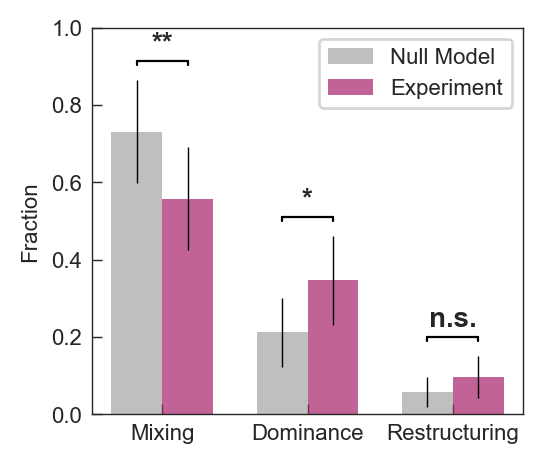

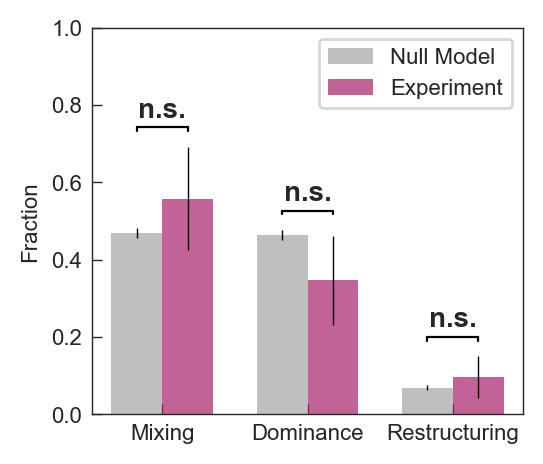

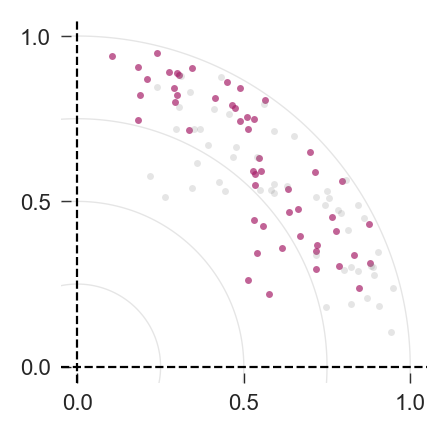

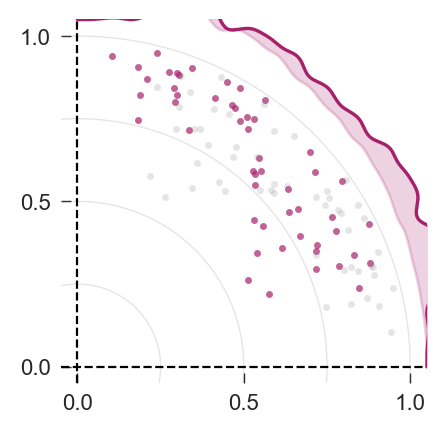

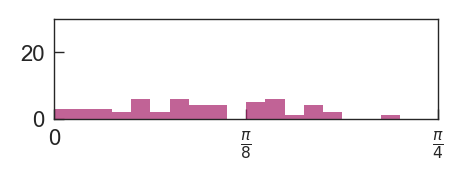

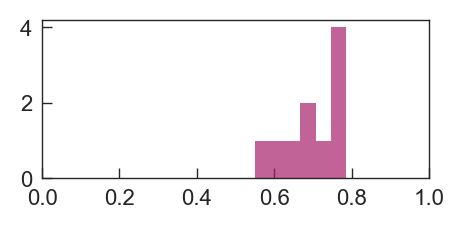

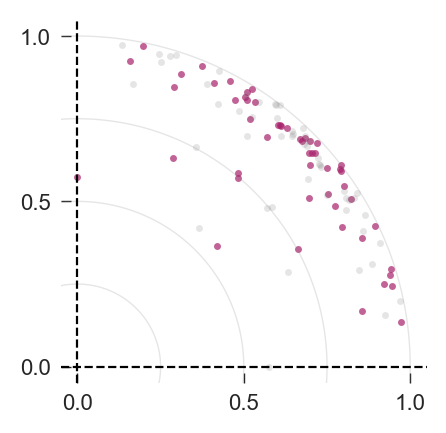

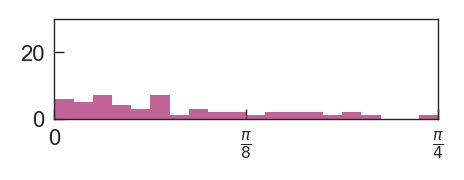

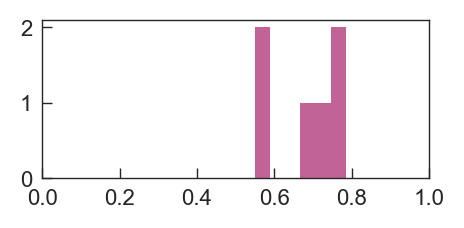

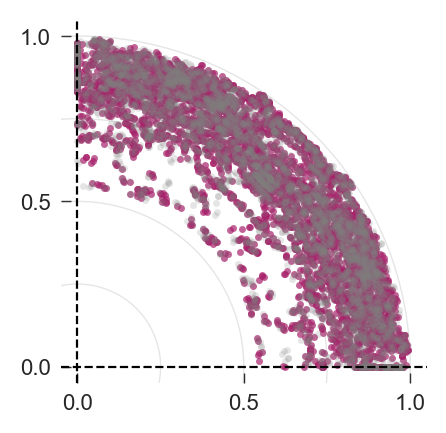

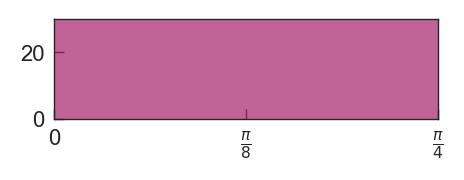

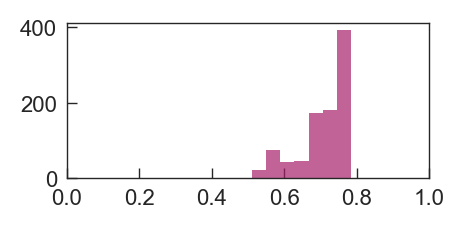

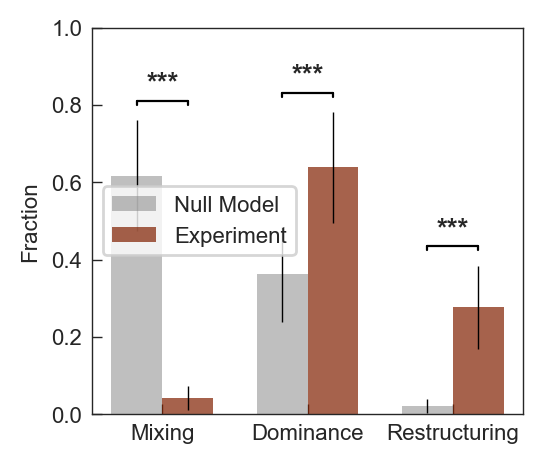

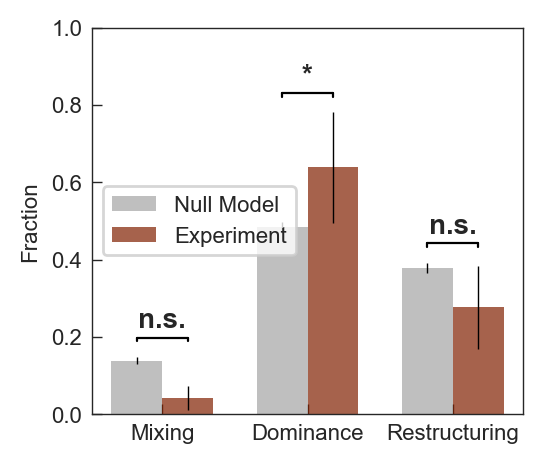

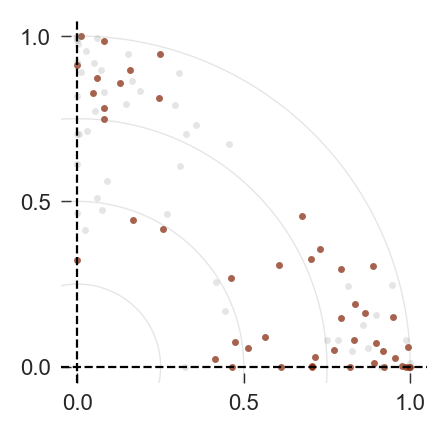

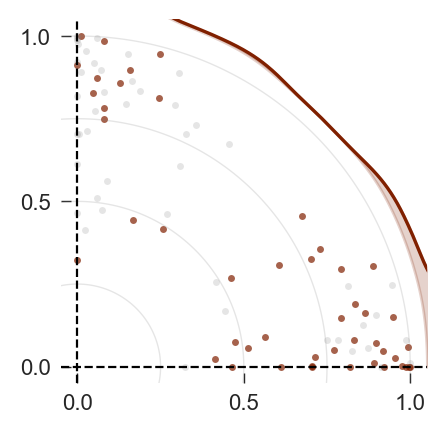

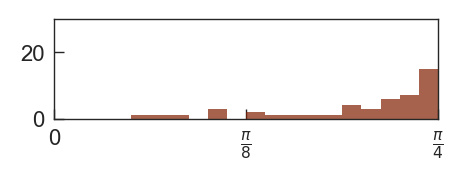

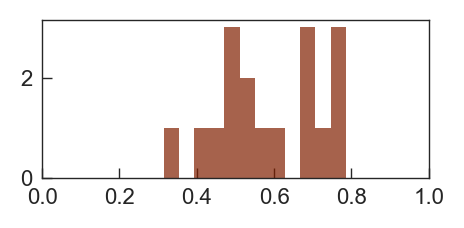

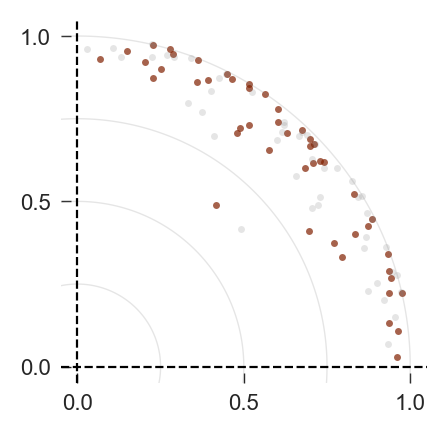

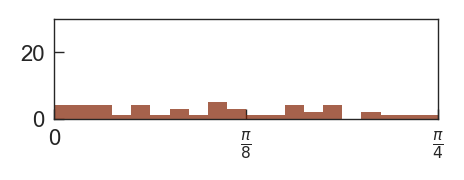

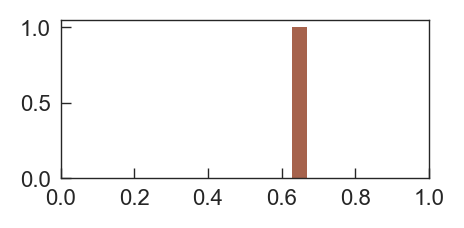

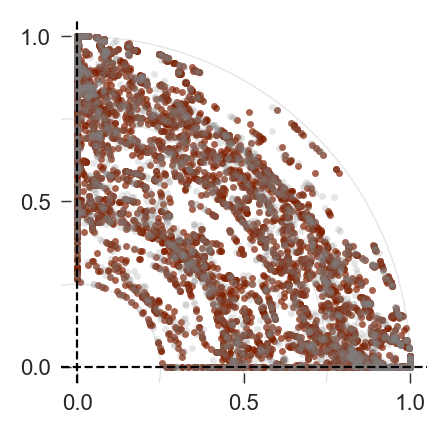

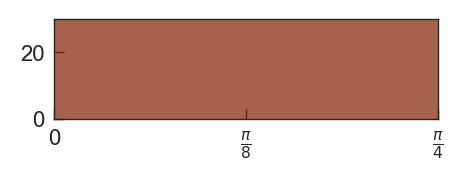

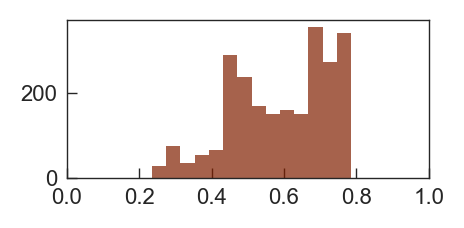

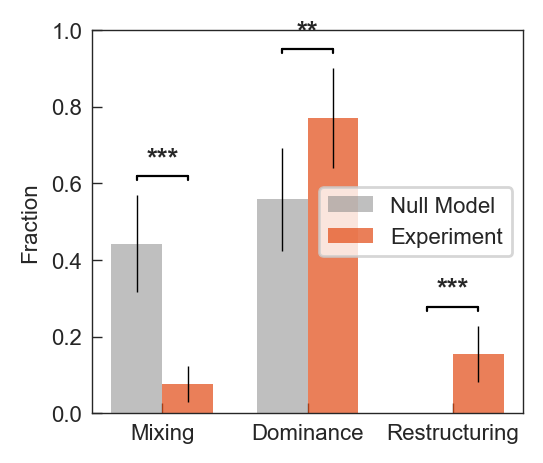

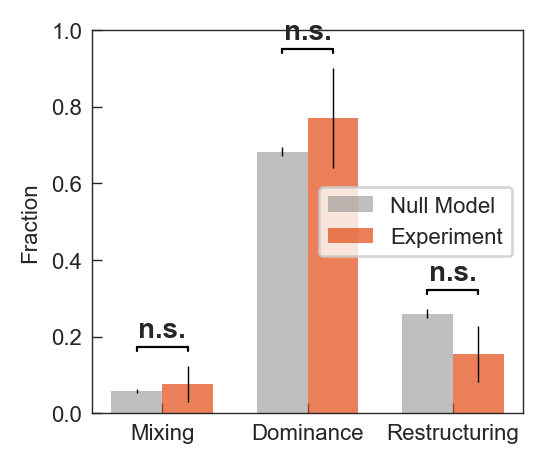

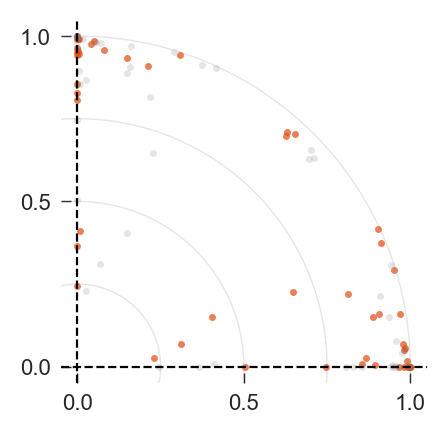

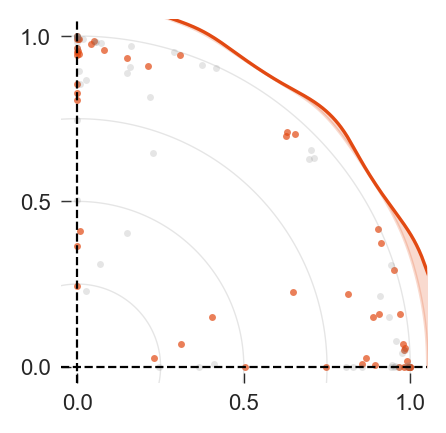

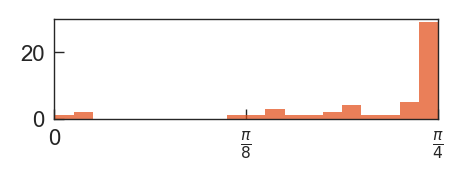

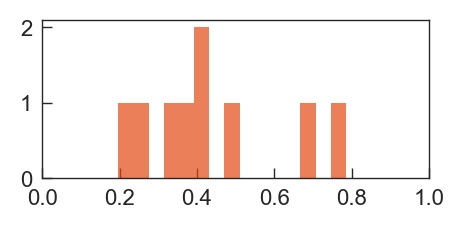

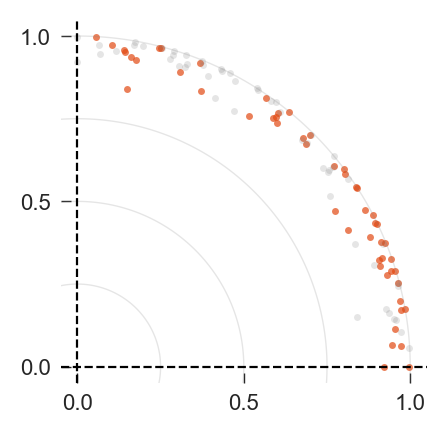

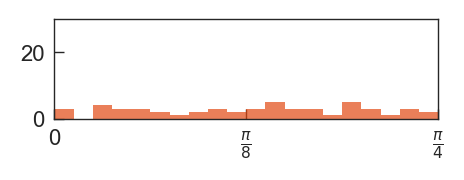

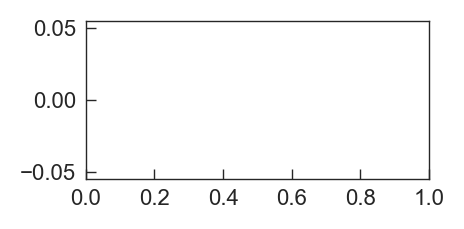

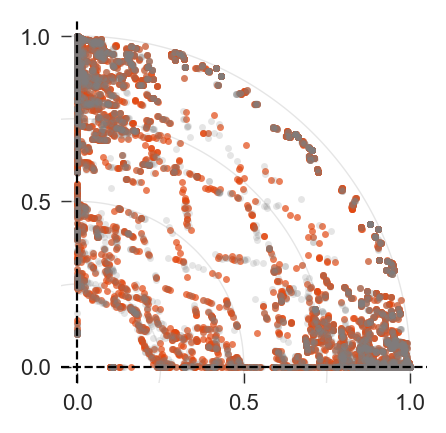

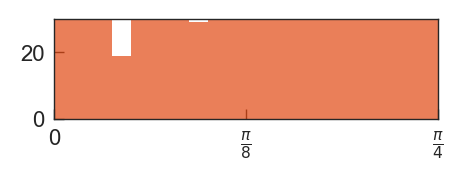

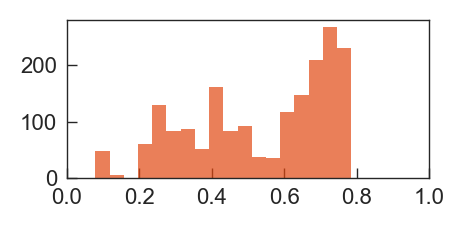

In [5]:
from scipy.stats import gaussian_kde
colors = ['#A7216A',  # rich magenta-purple
          '#802000',
          '#E24912',  # deep orange-red
          ]

'''
colors = ['#000000',  # black
          '#802000',  # dark burnt orange
          '#FFA500']  # standard orange'''

def thetaplot(data1, data2, color, smoothing=0.1):
    """
    Plots a folded smoothed histogram of θ = arctan(data1/data2), using |θ - π/4|,
    restricted to [0, π/4], with shading under the smoothed line.

    Parameters:
        data1, data2: Arrays of data points to compute θ
        c_i: Index for color choice (0 to 2) based on black-to-orange gradient
        smoothing: Bandwidth for KDE smoothing

    Returns:
        f: The matplotlib figure containing the histogram with shaded density
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import gaussian_kde

    mm = 1 / 25.4  # millimeter to inch conversion

    # Define color gradient: black → dark orange → orange
    colors = ['#000000', '#802000', '#FFA500']

    # Compute folded theta
    theta = np.abs(np.arctan2(data1, data2) - np.pi / 4)

    # Create figure
    f, ax = plt.subplots(figsize=(60 * mm, 25 * mm))

    # KDE smoothing
    kde = gaussian_kde(theta, bw_method=smoothing)
    theta_vals = np.linspace(0, np.pi / 4, 500)
    kde_vals = kde(theta_vals)

    # Plot histogram
    ax.hist(theta, bins=20, range=(0, np.pi/4), color=color, edgecolor='none',  alpha=0.7, density=False)

    # Fill under KDE curve
    #ax.fill_between(theta_vals, kde_vals, color=color, alpha=0.3)

    # Axis settings
    ax.set_xlim(0, np.pi / 4)
    ax.set_ylim(0, 30)
    ax.set_xticks([0, np.pi/8, np.pi/4])
    ax.set_xticklabels(['0', r'$\frac{\pi}{8}$', r'$\frac{\pi}{4}$'])

    plt.tight_layout()
    return f

def PolarizedThetaPlot(data1, data2):
    """
    Scatter plot of data1 vs data2 with mirrored symmetry, background contours,
    and a theta-based density curve along the quarter-circle boundary.

    Args:
        data1, data2: Arrays or lists of paired data values.

    Returns:
        f: Matplotlib figure object.
    """

    f, ax = plt.subplots(1, 1, figsize=(60 * mm, 60 * mm), facecolor='w', edgecolor='k')
    ax.scatter(data1, data2, s=25, color=colors[c_i], marker='.', alpha=0.7, linewidths=0)
    ax.scatter(data2, data1, s=25, color='grey', marker='.', alpha=0.2, linewidths=0)

    # Background radial contours
    x = np.linspace(-0.15, 1.2, 500)
    y = np.linspace(-0.15, 1.2, 500)
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)
    ax.contour(X, Y, R, levels=[0.25, 0.5, 0.75, 1.0], colors='grey', alpha=0.2, linewidths=0.5)

    # Axes lines
    ax.axhline(0, color='k', linestyle='--', linewidth=.8)
    ax.axvline(0, color='k', linestyle='--', linewidth=.8)

    # Add theta density curve along quarter circle
    theta = np.arctan2(data1, data2) - np.pi / 4
    theta = np.append(theta, -theta)  # Reflect for symmetry

    kde = gaussian_kde(theta, bw_method=0.1)
    theta_vals = np.linspace(-np.pi / 4, np.pi / 4, 500)
    density_vals = kde(theta_vals)

    # Convert polar to Cartesian coordinates for quarter arc
    r_base = 1.05
    r = r_base + 0.1 * density_vals
    x_theta = r * np.cos(theta_vals + np.pi / 4)
    y_theta = r * np.sin(theta_vals + np.pi / 4)

    ax.plot(x_theta, y_theta, color=colors[c_i], linewidth=1.2)
    ax.fill_betweenx(y_theta, x_theta, r_base * np.cos(theta_vals + np.pi / 4), color=colors[c_i], alpha=0.2)

    # Styling
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks([0, 0.5, 1.0])
    ax.set_yticks([0, 0.5, 1.0])
    for side in ['top', 'right', 'bottom', 'left']:
        ax.spines[side].set_visible(False)

    return f


def rplot(data1, data2, color='blue', smoothing=0.1):
    """
    Plots a smoothed histogram of r = sqrt(data1**2 + data2**2) with shading under the smoothed line.

    Parameters:
        data1, data2: Lists or arrays of data points to compute r
        color: Color of the histogram bars and KDE curve (default is blue)
        smoothing: Bandwidth for the KDE smoothing (default is 0.1)

    Returns:
        f: The matplotlib figure containing the histogram with shaded density
    """
    
    # Calculate r as the Euclidean distance
    r = np.sqrt(np.array(data1)**2 + np.array(data2)**2)
    
    # Create figure
    f, ax = plt.subplots(figsize=(60*mm,30*mm))
    
    # KDE for smoothing
    kde = gaussian_kde(r, bw_method=smoothing)
    r_vals = np.linspace(r.min(), r.max(), 500)
    kde_vals = kde(r_vals)
    
    # Plot the KDE line
    #ax.plot(r_vals, kde_vals, color=colors[c_i], linewidth=1.5, label='Smoothed Density')
    
    # Plot histogram
    ax.hist(r, bins=20, range=(0, np.pi/4), color=color, edgecolor='none',  alpha=0.7, density=False)

    # Fill under KDE curve
    #ax.fill_between(theta_vals, kde_vals, color=color, alpha=0.3)


    
    # Set labels and title
    #ax.set_xlabel(r'$r = \sqrt{\mathrm{data1}^2 + \mathrm{data2}^2}$')
    #ax.set_ylabel('Density')
    #ax.set_title('Histogram of r with Smoothing and Shaded Area')
    
    # Set x-axis limits based on range of r
    ax.set_xlim(0, 1)
    
    plt.tight_layout()
    
    return f

def print_class_fractions(data1, data2, type_name=None):
    """
    Calculates and prints the fraction of data points in each class.
    
    Parameters:
        data1, data2: Lists of data points to classify
        type_name: Optional name of the dataset for labeling output
    """
    class1_count = 0  # Dominance
    class2_count = 0  # Mixing
    class3_count = 0  # Restructuring
    
    for j in range(len(data1)):
        # Calculate asymmetricity
        x, y = calculate_assymetricity(data1[j], data2[j], 0)  # Pass 0 for k as it's not used
        
        # Determine class
        class_type = characterize_case(x, y)
        if class_type == 0:
            class1_count += 1
        elif class_type == 1:
            class2_count += 1
        else:
            class3_count += 1
    
    total_count = class1_count + class2_count + class3_count
    
    if total_count > 0:
        class1_fraction = class1_count / total_count
        class2_fraction = class2_count / total_count
        class3_fraction = class3_count / total_count
        
        label = f"{type_name} " if type_name else ""
        print(f"{label}Class Fractions:")
        print(f"  Dominance:    {class1_fraction:.2f} ({class1_count}/{total_count})")
        print(f"  Mixing:       {class2_fraction:.2f} ({class2_count}/{total_count})")
        print(f"  Restructuring: {class3_fraction:.2f} ({class3_count}/{total_count})")
        print("")
        
        return class1_fraction, class2_fraction, class3_fraction
    else:
        print(f"No data points to classify")
        return 0, 0, 0
    
def plot_class_fraction_comparison(class_counts_real, class_counts_null, total_real, total_null, color):
    """
    Plot grouped bar plot comparing class fractions between null and real models.
    Adds 95% binomial CI and significance stars for p-values.
    
    Returns:
        fig: the matplotlib figure object
    """
    # Class order
    class_names = ["Mixing", "Dominance", "Restructuring"]
    class_indices = [1, 0, 2]  # Reordering indices for correct class order

    # Reorder counts
    counts_real = [class_counts_real[i] for i in class_indices]
    counts_null = [class_counts_null[i] for i in class_indices]

    proportions_real = [counts_real[i] / total_real for i in range(3)]
    proportions_null = [counts_null[i] / total_null for i in range(3)]

    # Compute Wilson 95% CI
    ci_low_real, _ = proportion_confint(counts_real, total_real, alpha=0.05, method='wilson')
    ci_low_null, _ = proportion_confint(counts_null, total_null, alpha=0.05, method='wilson')
    errors_real = [p - l for p, l in zip(proportions_real, ci_low_real)]
    errors_null = [p - l for p, l in zip(proportions_null, ci_low_null)]

    # P-value testing
    p_values = [
        binomtest(counts_real[i], total_real, proportions_null[i], alternative='two-sided').pvalue
        for i in range(3)
    ]

    # Plot setup
    x = np.arange(3)
    bar_width = 0.35
    fig, ax = plt.subplots(figsize=(70 * mm, 60 * mm))  # Updated size in mm

    # Null model (left bars, grey)
    ax.bar(x - bar_width/2, proportions_null, bar_width, yerr=errors_null, capsize=0, alpha=0.5, edgecolor='none', error_kw={'elinewidth': .5, 'capthick': 0},
           label='Null Model', color='grey')

    # Real data (right bars, color-coded)
    ax.bar(x + bar_width/2, proportions_real, bar_width, yerr=errors_real, capsize=0, alpha=0.7, edgecolor='none', error_kw={'elinewidth': .5, 'capthick': 0},
           label='Experiment', color=color)

    # Axis settings
    ax.set_xticks(x)
    ax.set_xticklabels(class_names)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Fraction")
    ax.legend()

    # Annotate bars
    #for i in range(3):
    #    ax.text(x[i] - bar_width/2, proportions_null[i] + 0.02, f"{proportions_null[i]:.2f}",
    #            ha='center', va='bottom', fontsize=8)
    #    ax.text(x[i] + bar_width/2, proportions_real[i] + 0.02, f"{proportions_real[i]:.2f}",
    #            ha='center', va='bottom', fontsize=8)

    # Significance stars
    def p_to_stars(p):
        if p < 0.001:
            return '***'
        elif p < 0.01:
            return '**'
        elif p < 0.05:
            return '*'
        else:
            return 'n.s.'

    for i, p in enumerate(p_values):
        stars = p_to_stars(p)
        
        # Determine height for the line and star
        y1 = proportions_null[i] + errors_null[i]
        y2 = proportions_real[i] + errors_real[i]
        y = max(y1, y2) + 0.05  # vertical offset above the taller bar

        # Draw horizontal bracket
        ax.plot([x[i] - bar_width/2, x[i] + bar_width/2], [y, y], color='black', linewidth=0.8)
        ax.plot([x[i] - bar_width/2, x[i] - bar_width/2], [y - 0.01, y], color='black', linewidth=0.8)
        ax.plot([x[i] + bar_width/2, x[i] + bar_width/2], [y - 0.01, y], color='black', linewidth=0.8)
        
        # Add significance stars above the line
        ax.text(x[i], y + 0.01, stars, ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.tight_layout()
    return fig
        
########################################################
########################################################
# Metric1
########################################################
########################################################

## This figure shows the distribution of "Assymetricity"

## Coal Figure 2. Plot every variable - swarm&box

typeofplot = 'swarmpoint' 
to_plot_null = True
to_plot_subperturb = True

# Plotting real data
for c_i, type_name in enumerate(['LN_12', 'MN_12', 'HN_12']):
    Null_model_rep = 1
    
    # Get indices for the current type
    IDX_list = Syn_Coal_IDX[type_name]
    
    # Get parent sample indices
    idx = np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    
    # Get indices for the first components
    idx_1 = Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
    idx_1 = np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_1])
    
    # Get indices for the second components
    idx_2 = Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
    idx_2 = np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_2])
    
    # Get indices for the mixture
    idx = np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
    
    # Initialize data lists
    data1, data2, data_null_model_1, data_null_model_2, data_subperturb_1, data_subperturb_2 = [], [], [], [], [], []
    species_num = len(np.zeros(43))  # Get species number from data
    
    # Process each sample
    for i in range(len(idx)):
        for _ in range(Null_model_rep):
            # Get composition data
            c_mix = Processed_sequences_synthetic.iloc[idx[i]].values.tolist()[1:]
            c_1 = np.array(Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[1:])
            c_2 = np.array(Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[1:])
            
            # Filter small values
            c_1 = c_1 * (c_1 > 1e-4)
            c_2 = c_2 * (c_2 > 1e-4)
            
            
            if to_plot_null:
                # Create mock mixtures for null model
                mix_label = (np.random.rand(species_num))
                moc_c1 = c_1
                moc_c2 = c_2
                
                # Normalize
                moc_c_mix= (mix_label) * c_1 + mix_label * c_2
                moc_c_mix= moc_c_mix / (np.sum(moc_c_mix) + 1e-9)
                
                # Calculate F1 and F2 metrics
                u, v, k = metric_VectorDecomposition_onlyPositive(moc_c1, moc_c2, moc_c_mix)
                
                data_null_model_1.append(u)
                data_null_model_2.append(v)
            
            if to_plot_subperturb:
                for i in range(100):
                    try:
                    # Create mock mixtures for null model
                        mix_label = (np.random.rand(species_num) > 0.5).astype(int)
                        moc_c1 = (mix_label) * c_1 + (1 - mix_label) * c_2
                        moc_c2 = (1 - mix_label) * c_1 + (mix_label) * c_2
                        moc_c_mix = c_mix
                        # Normalize
                        moc_c1 = moc_c1 / (np.sum(moc_c1) + 1e-9)
                        moc_c2 = moc_c2 / (np.sum(moc_c2) + 1e-9)

                        # Calculate F1 and F2 metrics
                        u, v, k = metric_VectorDecomposition_onlyPositive(moc_c1, moc_c2, moc_c_mix)

                        F1 = np.sum(np.minimum(moc_c1, c_mix))
                        F2 = np.sum(np.minimum(moc_c2, c_mix))
                        
                        data_subperturb_1.append(u)
                        data_subperturb_2.append(v)
                    except:
                        pass
            
            if _ == 0:
                # Calculate metrics for real data
                u, v, k = metric_VectorDecomposition_onlyPositive(c_1, c_2, c_mix)
                data1.append(u)
                data2.append(v)
                
                # Debug output for unusual cases
                if u > 0.6 and v > 0.6:
                    print(type_name)
                    print(u, v, k)
                    
        # Calculate

    # Print the class fractions for each data type
    print(f"\n===== Class Fractions for {type_name} =====")
    # Get fractions for real data
    real_class1_frac, real_class2_frac, real_class3_frac = print_class_fractions(data1, data2, "Real Data")
    real_total = len(data1)
    real_counts = [int(real_class1_frac * real_total), int(real_class2_frac * real_total), int(real_class3_frac * real_total)]

    
    null_counts = []
    null_total = 0
    if to_plot_null:
        # Get fractions for null model
        null_class1_frac, null_class2_frac, null_class3_frac = print_class_fractions(data_null_model_1, data_null_model_2, "Null Model")
        null_total = len(data_null_model_1)
        null_counts = [int(null_class1_frac * null_total), int(null_class2_frac * null_total), int(null_class3_frac * null_total)]

    if to_plot_subperturb:
        subperturb_class1_frac, subperturb_class2_frac, subperturb_class3_frac = print_class_fractions(data_subperturb_1, data_subperturb_2, "Subperturb Model")
        subperturb_total = len(data_subperturb_1)
        subperturb_counts = [int(subperturb_class1_frac * subperturb_total), int(subperturb_class2_frac * subperturb_total), int(subperturb_class3_frac * subperturb_total)]
        
    # Plot comparison between real and null model
    if to_plot_null and len(null_counts) > 0:
        fig = plot_class_fraction_comparison(
            real_counts, 
            null_counts, 
            real_total, 
            null_total,
            color= colors[c_i],  # Use the same color for the real data
        )
        fig.savefig(f"Figure/ClassFractions_{type_name}_GroupedBarPlot.svg", bbox_inches='tight')
        
        fig = plot_class_fraction_comparison(
            real_counts, 
            subperturb_counts, 
            real_total, 
            subperturb_total,
            color= colors[c_i],  # Use the same color for the real data
        )
        fig.savefig(f"Figure/ClassFractions_{type_name}_GroupedBarPlot.svg", bbox_inches='tight')
        
        f=PolarizedPlot(data1,data2)
        f.savefig(f'Figure/Metric_metric3_{type_name}_style_Polarized.svg',bbox_inches='tight')

        f=PolarizedThetaPlot(data1,data2)
        f.savefig(f'Figure/Metric_metric3_{type_name}_style_PolarizedTheta.svg',bbox_inches='tight')

        f=thetaplot(data1, data2, colors[c_i])
        f.savefig(f'Figure/Metric_metric3_{type_name}_style_Theta.svg',bbox_inches='tight')
        
        f=rplot(data1, data2, color=colors[c_i])
        f.savefig(f'Figure/Metric_metric3_{type_name}_style_R.svg',bbox_inches='tight')

        f= PolarizedPlot(data_null_model_1,data_null_model_2)
        f.savefig(f'Figure/Metric_metric3_{type_name}_null_style1_Polarized.svg',bbox_inches='tight')

        f = thetaplot(data_null_model_1, data_null_model_2, colors[c_i])
        f.savefig(f'Figure/Metric_metric3_{type_name}_null_style1_Theta.svg', bbox_inches='tight')
        
        f = rplot(data_null_model_1, data_null_model_2, color=colors[c_i])
        f.savefig(f'Figure/Metric_metric3_{type_name}_null_style1_R.svg', bbox_inches='tight')
        
        f= PolarizedPlot(data_subperturb_1,data_subperturb_2)
        f.savefig(f'Figure/Metric_metric3_{type_name}_subperturb_style1_Polarized.svg',bbox_inches='tight')

        f = thetaplot(data_subperturb_1,data_subperturb_2, colors[c_i])
        f.savefig(f'Figure/Metric_metric3_{type_name}_subperturb_style1_Theta.svg', bbox_inches='tight')
        
        f = rplot(data_subperturb_1, data_subperturb_2, color=colors[c_i])
        f.savefig(f'Figure/Metric_metric3_{type_name}_subperturb_style1_R.svg', bbox_inches='tight')

In [6]:


# From your previous function or loop
real_counts = [class1_count, class2_count, class3_count]
null_counts = [null_class1, null_class2, null_class3]
total_real = sum(real_counts)
total_null = sum(null_counts)

plot_class_fraction_comparison(real_counts, null_counts, total_real, total_null)


NameError: name 'class1_count' is not defined

# Using the Enhanced VariousMetrics Module

The enhanced VariousMetrics module now includes the corrected vector decomposition function that matches the `metric_VectorDecomposition_onlyPositive` implementation from this notebook.

In [ ]:
# Import required libraries
import numpy as np
import VariousMetrics as vm

# Example usage with the corrected vector decomposition
parent1_example = np.array([25, 15, 10, 8, 5, 3, 2, 1])
parent2_example = np.array([5, 8, 12, 15, 10, 6, 3, 2])
offspring_example = np.array([18, 14, 11, 11, 8, 5, 2, 1])

# Method 1: Legacy function (exact match to metric_VectorDecomposition_onlyPositive)
x1, x2, x3 = vm.metric_VectorDecomposition_onlyPositive(parent1_example, parent2_example, offspring_example)
print(f"Vector Decomposition Results:")
print(f"  Coefficient Parent 1: {x1:.4f}")
print(f"  Coefficient Parent 2: {x2:.4f}")
print(f"  Residual Magnitude: {x3:.4f}")
print(f"  Total magnitude check: {np.sqrt(x1**2 + x2**2 + x3**2):.4f}")

# Method 2: Comprehensive analysis
result = vm.analyze_coalescence_event(offspring_example, parent1_example, parent2_example)
decomp = result['coalescence_vector_decomposition']
print(f"\nComprehensive Analysis:")
print(f"  Coalescence Type: {result['coalescence_type']}")
print(f"  Asymmetricity: {result['asymmetricity']['magnitude']:.4f}")
print(f"  Vector coefficients match: {np.allclose([x1, x2, x3], [decomp['coefficient_parent1'], decomp['coefficient_parent2'], decomp['residual_magnitude']])}")

# The enhanced module provides all the same functionality as the notebook functions
# plus additional analysis capabilities for population-level studies

NameError: name 'np' is not defined